In [ ]:
# Install the data provider
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set visual style for professional reports
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# Define the ticker (S&P 500) and the timeframe
ticker = "^GSPC"
start_date = "2019-01-01"
end_date = "2024-01-01"

# Fetch data
raw_data = yf.download(ticker, start=start_date, end=end_date)

# Professional Cleaning: Keep only 'Close' price and ensure no missing values
# We use .copy() to avoid 'SettingWithCopy' warnings in Pandas
df = raw_data[['Close']].copy()
df.dropna(inplace=True)

print(f"Dataset Loaded: {len(df)} days of trading data.")

/tmp/ipykernel_4304/3844967292.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Dataset Loaded: 1258 days of trading data.


In [ ]:
# 1. Calculate Daily Returns (Percentage Change)
df['Returns'] = df['Close'].pct_change()

# 2. Calculate Rolling Volatility (21-day Standard Deviation)
# We multiply by sqrt(252) to 'Annualize' it (Standard Finance Practice)
df['Volatility'] = df['Returns'].rolling(window=21).std() * np.sqrt(252)

# 3. Create a 'Risk Level' Label using NumPy
# If Volatility is > 20%, it's 'High Risk'. If < 12%, it's 'Low Risk'.
df['Risk_Level'] = np.where(df['Volatility'] > 0.20, 'High',
                   np.where(df['Volatility'] < 0.12, 'Low', 'Normal'))

print(df[['Close', 'Volatility', 'Risk_Level']].tail(10))

Price             Close Volatility Risk_Level
Ticker            ^GSPC                      
Date                                         
2023-12-15  4719.189941   0.069395        Low
2023-12-18  4740.560059   0.069718        Low
2023-12-19  4768.370117   0.070591        Low
2023-12-20  4698.350098   0.090436        Low
2023-12-21  4746.750000   0.094260        Low
2023-12-22  4754.629883   0.094016        Low
2023-12-26  4774.750000   0.094154        Low
2023-12-27  4781.580078   0.092988        Low
2023-12-28  4783.350098   0.093127        Low
2023-12-29  4769.830078   0.094187        Low


In [ ]:
# Flatten the columns to remove the 'Ticker' level
df.columns = df.columns.get_level_values(0)

# Now, ensure 'Close' is a single Series, not a DataFrame
df_close = df['Close']

# Retry Phase 4 with the simplified data
df['Peak'] = df_close.cummax()
df['Drawdown'] = (df_close - df['Peak']) / df['Peak']
max_drawdown = df['Drawdown'].min()

print(f"Professional Risk Insight: The Maximum Drawdown was {max_drawdown:.2%}")

Professional Risk Insight: The Maximum Drawdown was -33.92%


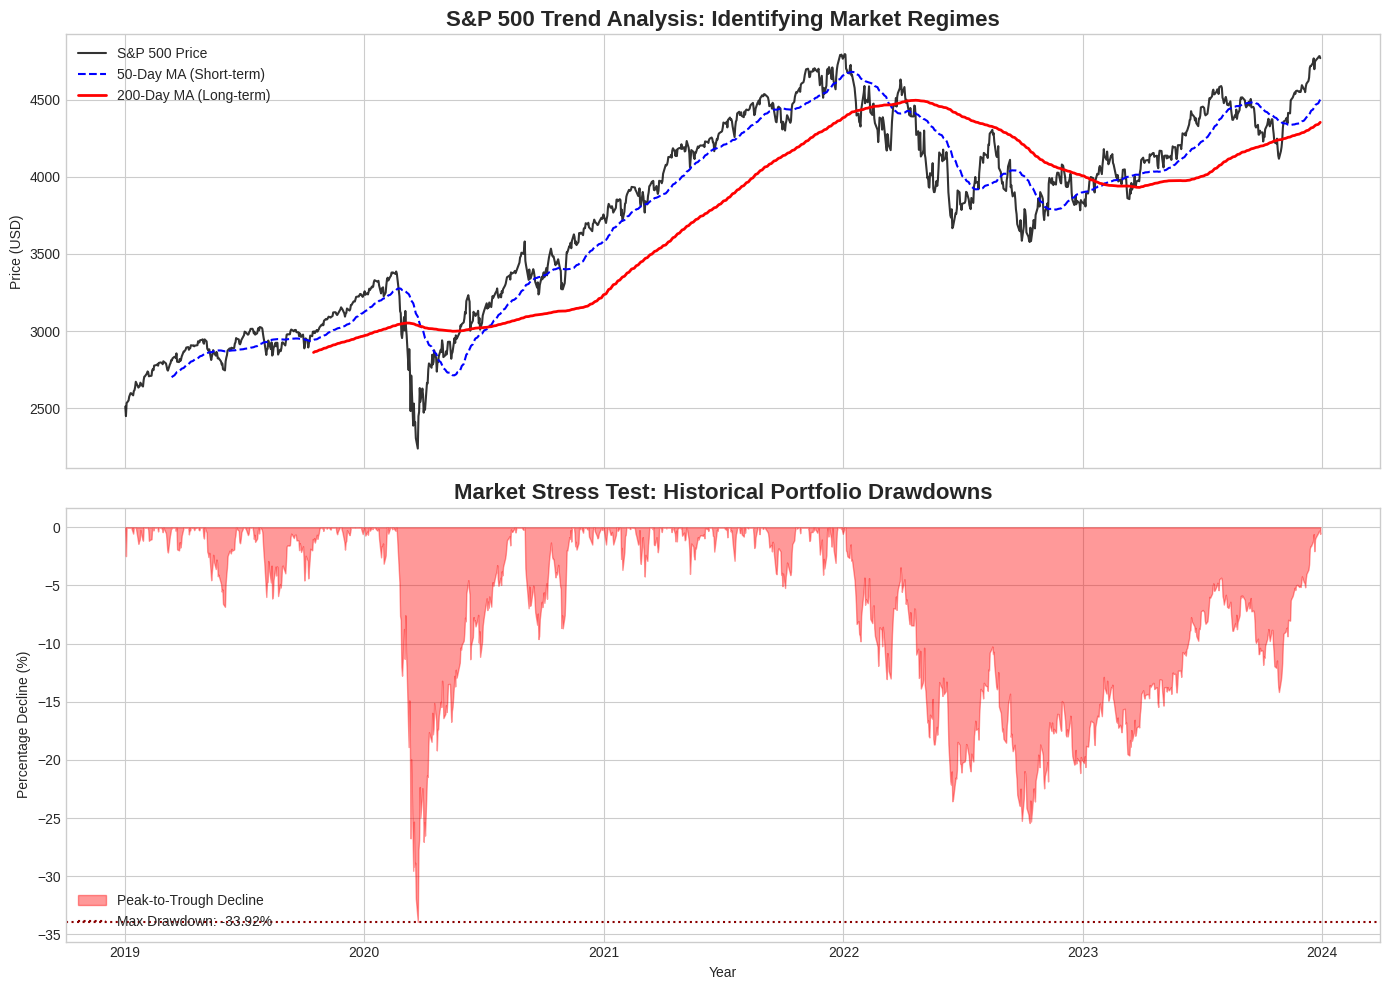

In [ ]:
import matplotlib.pyplot as plt

# Set up the dashboard layout (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- CHART 1: TREND ANALYSIS ---
ax1.plot(df.index, df['Close'], label='S&P 500 Price', color='black', linewidth=1.5, alpha=0.8)
ax1.plot(df.index, df['Close'].rolling(window=50).mean(), label='50-Day MA (Short-term)', color='blue', linestyle='--')
ax1.plot(df.index, df['Close'].rolling(window=200).mean(), label='200-Day MA (Long-term)', color='red', linewidth=2)

ax1.set_title('S&P 500 Trend Analysis: Identifying Market Regimes', fontsize=16, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')

# --- CHART 2: RISK STRESS TEST (DRAWDOWN) ---
ax2.fill_between(df.index, df['Drawdown'] * 100, 0, color='red', alpha=0.4, label='Peak-to-Trough Decline')
ax2.axhline(y=max_drawdown * 100, color='darkred', linestyle=':', label=f'Max Drawdown: {max_drawdown:.2%}')

ax2.set_title('Market Stress Test: Historical Portfolio Drawdowns', fontsize=16, fontweight='bold')
ax2.set_ylabel('Percentage Decline (%)')
ax2.set_xlabel('Year')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

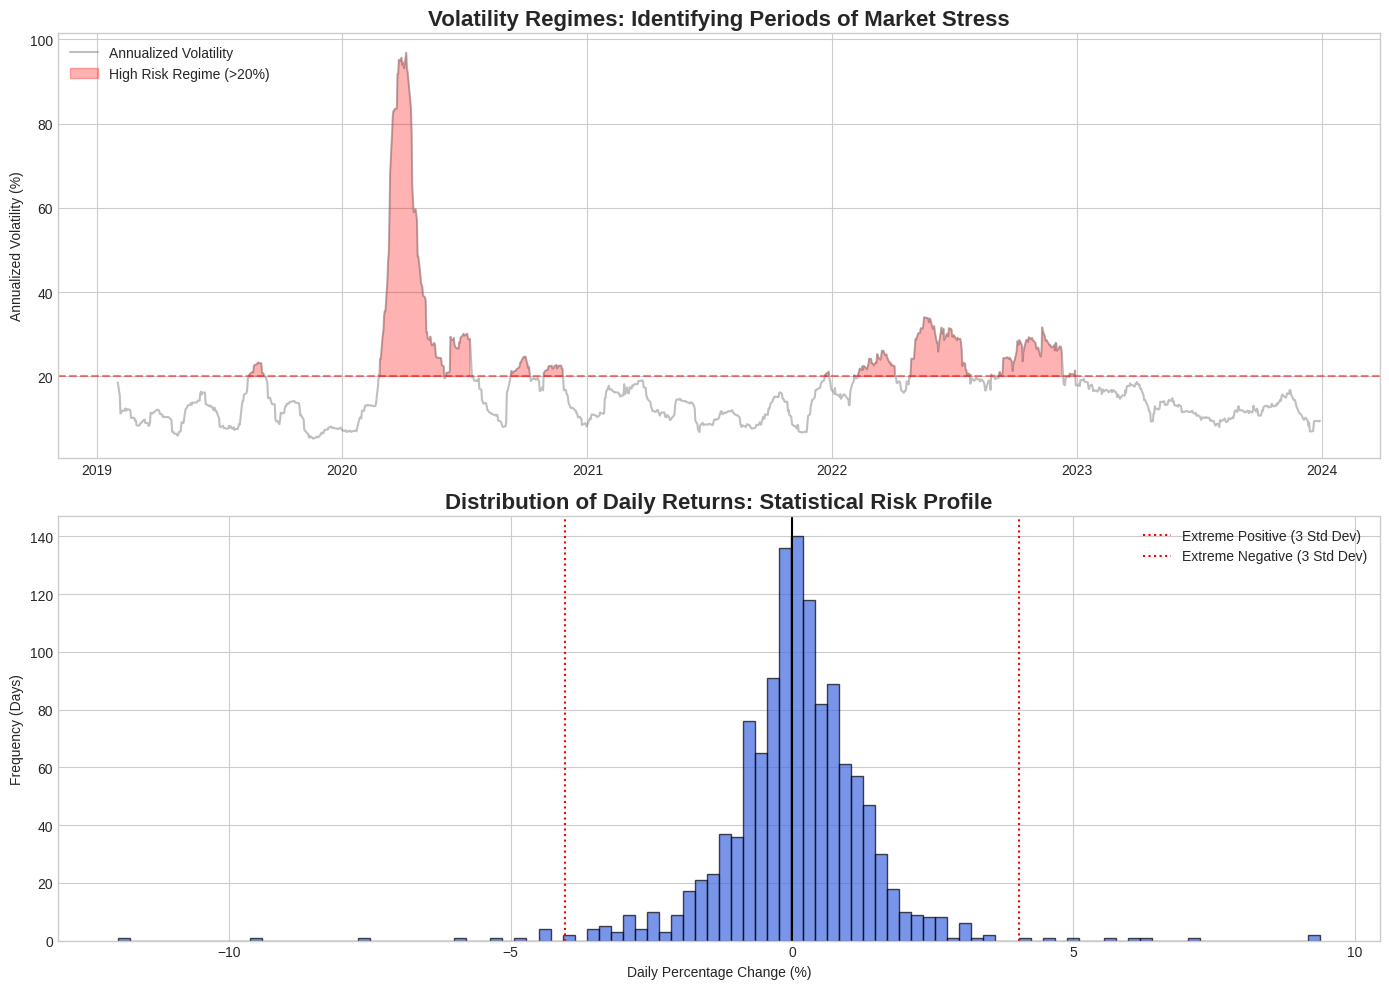

In [ ]:
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 10))

# --- CHART 3: VOLATILITY REGIMES ---
# We use a fill_between to highlight 'High Risk' zones (> 20% Volatility)
ax3.plot(df.index, df['Volatility'] * 100, color='gray', alpha=0.5, label='Annualized Volatility')
ax3.fill_between(df.index, df['Volatility'] * 100, 20, where=(df['Volatility'] * 100 > 20),
                 color='red', alpha=0.3, label='High Risk Regime (>20%)')
ax3.axhline(y=20, color='red', linestyle='--', alpha=0.5)

ax3.set_title('Volatility Regimes: Identifying Periods of Market Stress', fontsize=16, fontweight='bold')
ax3.set_ylabel('Annualized Volatility (%)')
ax3.legend(loc='upper left')

# --- CHART 4: DISTRIBUTION OF RETURNS (The 'Bell Curve') ---
# This shows how often the market moves by certain percentages
ax4.hist(df['Returns'].dropna() * 100, bins=100, color='royalblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0, color='black', linestyle='-')

# Adding 'Risk' lines (3 Standard Deviations)
std_dev = df['Returns'].std() * 100
ax4.axvline(x=3*std_dev, color='red', linestyle=':', label='Extreme Positive (3 Std Dev)')
ax4.axvline(x=-3*std_dev, color='red', linestyle=':', label='Extreme Negative (3 Std Dev)')

ax4.set_title('Distribution of Daily Returns: Statistical Risk Profile', fontsize=16, fontweight='bold')
ax4.set_xlabel('Daily Percentage Change (%)')
ax4.set_ylabel('Frequency (Days)')
ax4.legend()

plt.tight_layout()
plt.show()

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. CREATE THE INTERACTIVE FUNCTION
def run_risk_analysis(years):
    # 'output' refers to the display area we create below
    with output:
        clear_output(wait=True)

        # Pull data based on the slider value
        df_new = yf.download('^GSPC', period=f"{years}y")
        df_new.columns = df_new.columns.get_level_values(0)

        # Calculate Risk Metrics on the fly
        df_new['Peak'] = df_new['Close'].cummax()
        df_new['Drawdown'] = (df_new['Close'] - df_new['Peak']) / df_new['Peak']
        current_max_dd = df_new['Drawdown'].min()

        # Create the dynamic Plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        ax1.plot(df_new['Close'], color='black', linewidth=1.5)
        ax1.set_title(f'S&P 500 Performance: Last {years} Years', fontsize=14, fontweight='bold')

        ax2.fill_between(df_new.index, df_new['Drawdown']*100, 0, color='red', alpha=0.3)
        ax2.set_title(f'Interactive Stress Test: Max Drawdown is {current_max_dd:.2%}', color='darkred')
        ax2.set_ylabel('Decline (%)')

        plt.tight_layout()
        plt.show()

# 2. SETUP THE INTERFACE
# Create the slider and the output area
year_slider = widgets.IntSlider(value=5, min=1, max=10, step=1, description='Years:')
output = widgets.Output()

# 3. LINK THE SLIDER TO THE FUNCTION
def on_value_change(change):
    run_risk_analysis(change['new'])

year_slider.observe(on_value_change, names='value')

# 4. DISPLAY
display(year_slider, output)
run_risk_analysis(5) # Start the dashboard with 5 years as default

IntSlider(value=5, description='Years:', max=10, min=1)

Output()